In [3]:
# Load the required Python Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [4]:
# Step 1: Load the dataset
# Load the DataCo Smart Supply Chain dataset into a Pandas DataFrame.
df = pd.read_csv('DataCoSupplyChainDataset.csv',encoding="latin1")
df.shape

(180519, 53)

In [5]:
# Step 2: Initial Data Assessment
# Perform a quick assessment of the dataset to understand:
# - Data types
# - Missing values
# - Number of unique values

summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'unique_values': df.nunique()
})

summary.sort_values('unique_values')

,dtype,missing,unique_values
Product Description,float64,180519,0
Customer Password,object,0,1
Product Status,int64,0,1
Customer Email,object,0,1
Late_delivery_risk,int64,0,2
Customer Country,object,0,2
Customer Segment,object,0,3
Delivery Status,object,0,4
Days for shipment (scheduled),int64,0,4
Shipping Mode,object,0,4


In [6]:
# Step 3: Target Variable Exploration
# The target selected for this project is:Late_delivery_risk
# This step evaluates the distribution of the target variable and checks whether the
# dataset is balanced or imbalanced before model training.
df['Late_delivery_risk'].value_counts()

,count
Late_delivery_risk,
1,98977
0,81542


In [7]:
# Step 4: Numerical Correlation Analysis
# Calculate correlations between numerical variables and the target variable.
# The goal is to identify numerical features that may have predictive value
# for shipment delay prediction.

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

corr = df[numeric_cols].corr()['Late_delivery_risk']

corr.sort_values(ascending=False)

,Late_delivery_risk
Late_delivery_risk,1.000000
Days for shipping (real),0.401415
Customer Zipcode,0.003148
Category Id,0.001752
Product Category Id,0.001752
Order Item Cardprod Id,0.001490
Product Card Id,0.001490
Order Customer Id,0.001484
Customer Id,0.001484
Department Id,0.001077


In [8]:
# Step 5: Based on data understanding, one sample leakage investigation is performed
# Analyze the relationship between Delivery Status and Late_delivery_risk.
# This step is used to identify potential target leakage.
# Delivery Status appears to directly reveal shipment outcomes and therefore
# should not be used as a predictive feature.
pd.crosstab(df['Delivery Status'], df['Late_delivery_risk'],normalize='index') *100

Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,100.0,0.0
Late delivery,0.0,100.0
Shipping canceled,100.0,0.0
Shipping on time,100.0,0.0


In [9]:
# Step 6: Initial Feature Selection
# Based on EDA, candidate numerical and categorical features were selected for modeling.
num_imp_features = [
    'Days for shipment (scheduled)',
    'Product Price',
    'Order Item Quantity',
    'Sales',
    'Order Profit Per Order',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Total',
    'Benefit per order'
]

cat_imp_features = [
    'Shipping Mode',
    'Market',
    'Customer Segment',
    'Order Region',
    'Category Name',
    'Department Name',
    'Order Country',
    'Customer Country',
    'Type'
]

In [10]:
# Step 7: Numerical Feature Evaluation
# Calculate correlation values between selected numerical features and the target variable.
# This provides additional evidence supporting feature selection decisions.
for col in num_imp_features:
    corr = df[col].corr(df['Late_delivery_risk'])
    print(f"{col}: {corr:.4f}")

Days for shipment (scheduled): -0.3694
Product Price: -0.0022
Order Item Quantity: -0.0001
Sales: -0.0036
Order Profit Per Order: -0.0037
Order Item Discount: -0.0007
Order Item Discount Rate: 0.0004
Order Item Total: -0.0038
Benefit per order: -0.0037


In [11]:
# Step 8: Categorical Feature Evaluation
# Evaluate relationships between categorical variables and shipment delays
# using cross-tabulation.
# The objective is to identify categories associated with higher delay rates.

for col in cat_imp_features:
  display(pd.crosstab(df[col], df['Late_delivery_risk'],normalize='index') *100)

Late_delivery_risk,0,1
Shipping Mode,,
First Class,4.677501,95.322499
Same Day,54.256958,45.743042
Second Class,23.367219,76.632781
Standard Class,61.928317,38.071683


Late_delivery_risk,0,1
Market,,
Africa,45.410711,54.589289
Europe,44.792247,55.207753
LATAM,45.644842,54.355158
Pacific Asia,44.953951,55.046049
USCA,45.199426,54.800574


Late_delivery_risk,0,1
Customer Segment,,
Consumer,45.191650,54.808350
Corporate,45.277337,54.722663
Home Office,44.929560,55.070440


Late_delivery_risk,0,1
Order Region,,
Canada,51.199166,48.800834
Caribbean,46.922337,53.077663
Central Africa,42.039356,57.960644
Central America,45.245404,54.754596
Central Asia,44.665461,55.334539
East Africa,44.060475,55.939525
East of USA,44.338395,55.661605
Eastern Asia,45.673077,54.326923
Eastern Europe,44.336735,55.663265


Late_delivery_risk,0,1
Category Name,,
Accessories,43.033708,56.966292
As Seen on TV!,42.647059,57.352941
Baby,47.342995,52.657005
Baseball & Softball,44.778481,55.221519
Basketball,44.776119,55.223881
Books,43.456790,56.543210
Boxing & MMA,43.735225,56.264775
CDs,47.970480,52.029520
Cameras,41.891892,58.108108


Late_delivery_risk,0,1
Department Name,,
Apparel,45.252867,54.747133
Book Shop,43.456790,56.543210
Discs Shop,45.557749,54.442251
Fan Shop,45.225169,54.774831
Fitness,44.453409,55.546591
Footwear,45.273666,54.726334
Golf,45.219747,54.780253
Health and Beauty,44.198895,55.801105
Outdoors,44.507537,55.492463


Late_delivery_risk,0,1
Order Country,,
Afganistán,42.944785,57.055215
Albania,40.540541,59.459459
Alemania,43.716018,56.283982
Angola,40.196078,59.803922
Arabia Saudí,42.325581,57.674419
...,...,...
Vietnam,47.952444,52.047556
Yemen,40.845070,59.154930
Yibuti,32.258065,67.741935


Late_delivery_risk,0,1
Customer Country,,
EE. UU.,45.129829,54.870171
Puerto Rico,45.236619,54.763381


Late_delivery_risk,0,1
Type,,
CASH,43.367659,56.632341
DEBIT,42.782308,57.217692
PAYMENT,42.470941,57.529059
TRANSFER,51.456408,48.543592


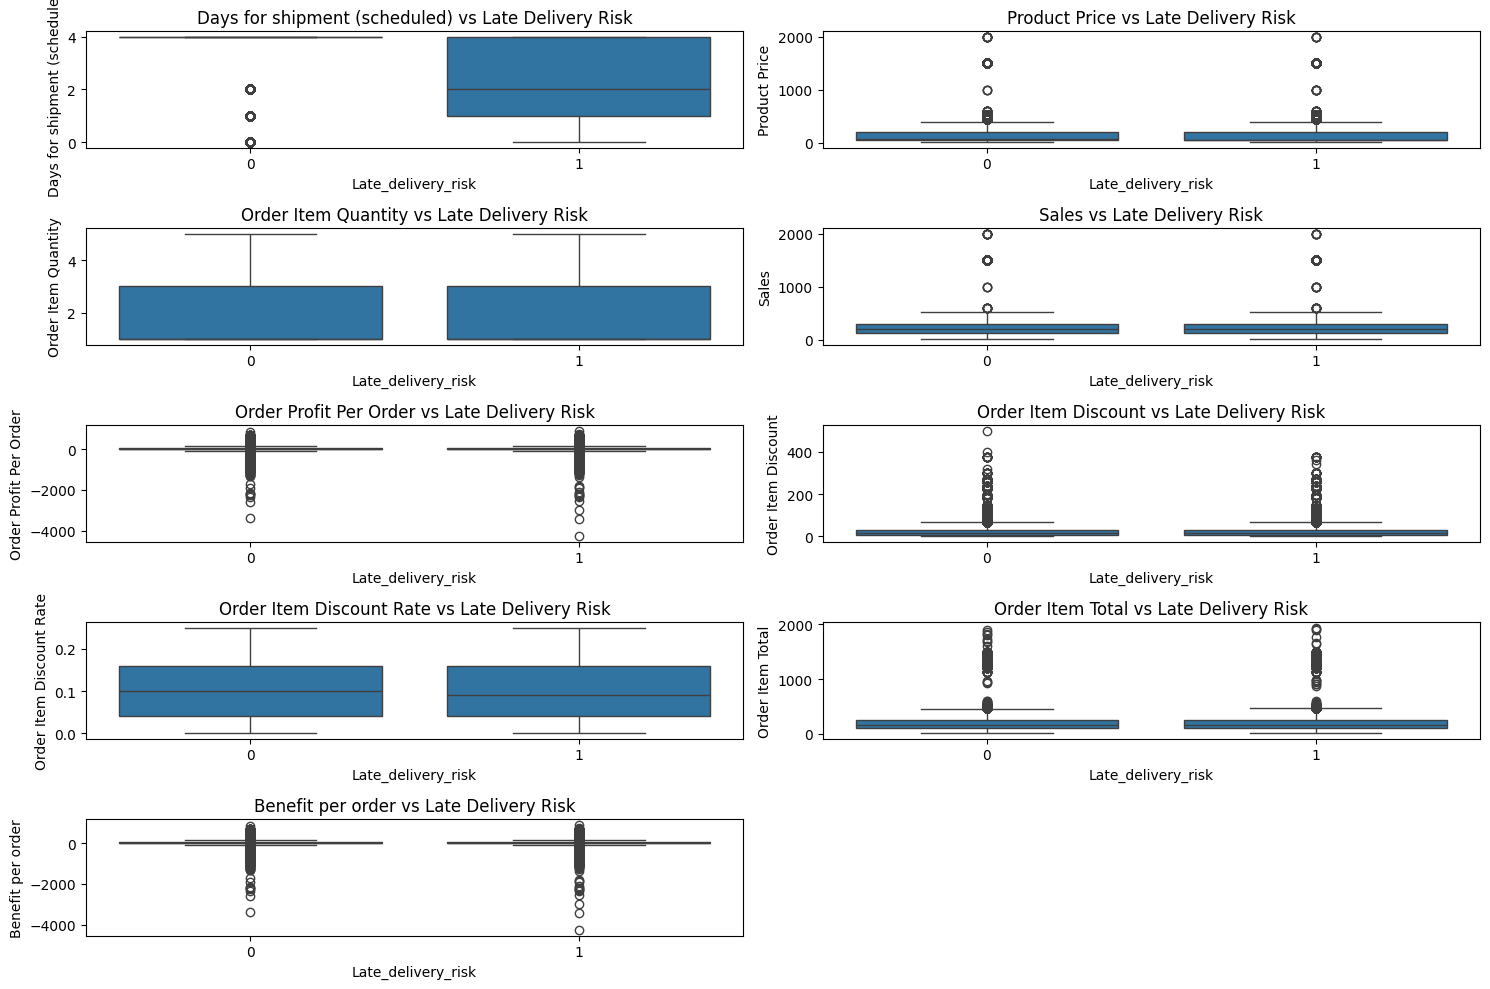

In [12]:
# Step 9: Numerical Feature Visualization
# Create boxplots for selected numerical variables against the target variable.
# These visualizations help identify:
# - Distribution differences
# - Outliers
# - Potential relationships with shipment delays

plt.figure(figsize=(15,10))

for i, feature in enumerate(num_imp_features, 1):
    plt.subplot(5, 2, i)

    sns.boxplot(
        x='Late_delivery_risk',
        y=feature,
        data=df
    )

    plt.title(f'{feature} vs Late Delivery Risk')

plt.tight_layout()
plt.show()

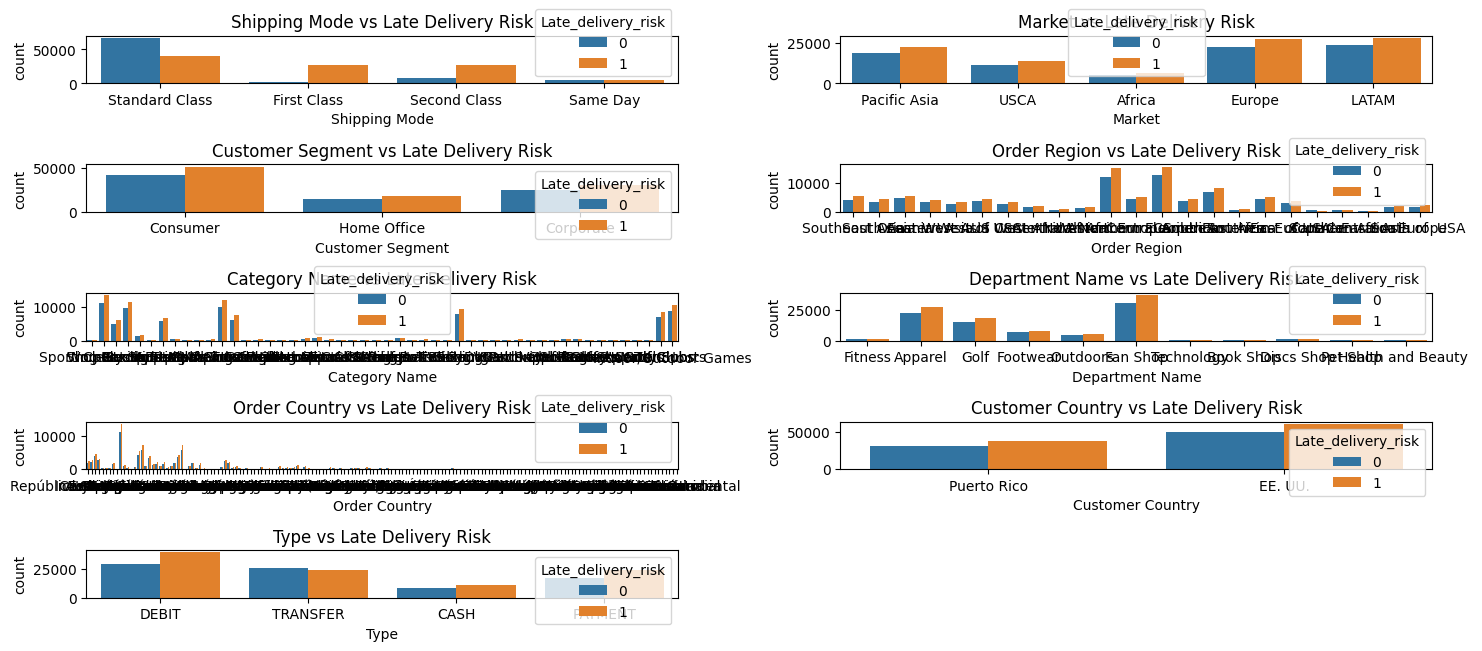

In [13]:
# Step 10: Categorical Feature Visualization
# Create count plots to visualize the distribution of shipment delays
# across categorical variables.
plt.figure(figsize=(15,10))

for i, feature in enumerate(cat_imp_features, 1):
    plt.subplot(8, 2, i)

    sns.countplot(
        x=feature,
        hue='Late_delivery_risk',
        data=df
    )

    plt.title(f'{feature} vs Late Delivery Risk')

plt.tight_layout()
plt.show()

In [14]:
# Step 11: Prepare Modeling Dataset
# Combine the selected numerical and categorical features into a single feature matrix.
feature_list = num_imp_features + cat_imp_features
target = 'Late_delivery_risk'

X = df[feature_list]
y = df[target]
y.value_counts()

,count
Late_delivery_risk,
1,98977
0,81542


In [15]:
# Step 12: Encode Categorical Variables
# Machine learning algorithms cannot directly process text-based categorical values.
# One-hot encoding is applied to convert categorical variables
# into numerical format suitable for model training.
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Columns: 266 entries, Days for shipment (scheduled) to Type_TRANSFER
dtypes: bool(257), float64(7), int64(2)
memory usage: 56.6 MB


In [16]:
# Step 13: Train-Test Split
# Split the dataset into training and testing datasets.
# Training data is used to build the model.
# Testing data is reserved for evaluating model performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [17]:
# Step 14: Verify Dataset Sizes
print(X_train.shape)
print(X_test.shape)

(126363, 266)
(54156, 266)


In [18]:
# Step 15: Train Random Forest Model
# Train a Random Forest classifier using the selected features.
# Configuration choices:
# - Balanced class weighting to address class imbalance
# - Controlled tree depth to reduce overfitting
# - Multiple trees to improve model stability
# This serves as the initial predictive model for shipment delay prediction.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
# n_estimators - Number of trees in the forest.
# max_depth - How deep the tree can grow
# n_jobs = All CPU cores available
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, n_jobs=-1,
                       random_state=42)

In [19]:
# Step 16: Generate Predictions
# Generate shipment delay predictions for the test dataset.
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [20]:
# Step 17: Model Evaluation
# Evaluate Random Forest performance
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.692111677376468
Precision: 0.7976043523979335
Recall: 0.5875458862358132
F1 Score: 0.6766474033277741
ROC-AUC: 0.7261671499622349


In [21]:
# Step 18: Feature Importance Analysis
# Extract feature importance scores from the Random Forest model.
# This analysis helps identify the strongest drivers of shipment delays

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
)

importance = importance.sort_values(ascending=False)
print(importance.head(20))

Shipping Mode_Standard Class     0.341380
Days for shipment (scheduled)    0.283395
Shipping Mode_Second Class       0.224792
Type_TRANSFER                    0.046001
Shipping Mode_Same Day           0.017695
Type_DEBIT                       0.014476
Type_PAYMENT                     0.010548
Order Profit Per Order           0.004561
Order Item Discount              0.004169
Benefit per order                0.003971
Order Item Total                 0.003718
Order Item Discount Rate         0.002512
Product Price                    0.002013
Sales                            0.001921
Order Country_Cuba               0.001514
Order Region_Western Europe      0.001276
Customer Segment_Home Office     0.001147
Order Country_Estonia            0.000990
Order Country_Argentina          0.000946
Customer Segment_Corporate       0.000855
dtype: float64


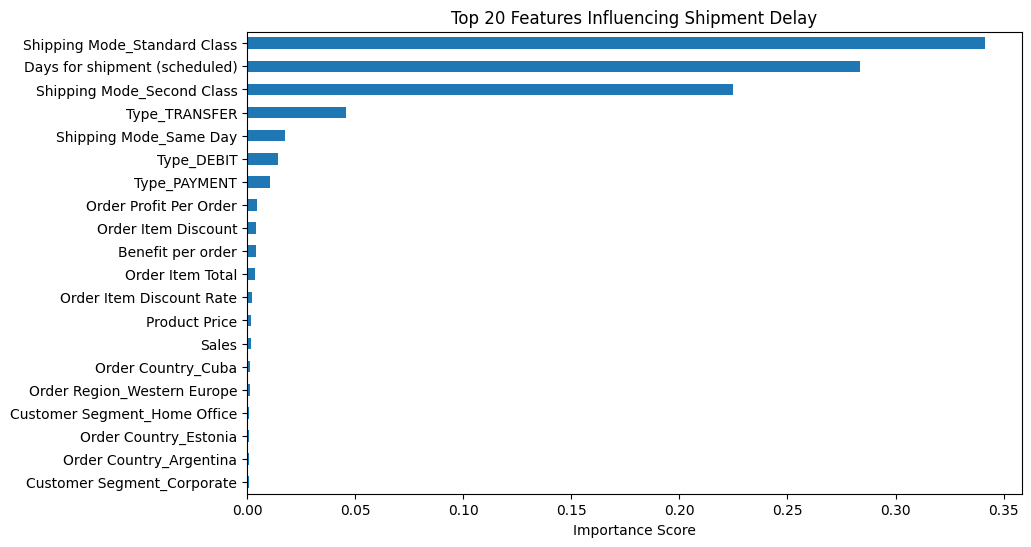

In [22]:
# Step 19: Visualize Key Drivers of Shipment Delay
# Plot the top features influencing shipment delays.
# Current findings suggest that:
# - Shipping Mode
# - Days for Shipment (Scheduled)
# - Transaction Type
# are the most influential predictors of shipment delays.
# Financial metrics such as Sales and Product Price appear to have relatively little impact.

importance.head(20).sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top 20 Features Influencing Shipment Delay")
plt.xlabel("Importance Score")

plt.show()

In [23]:
# =====================================================
# SECTION 20 - TRAIN MULTIPLE MODELS
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=500
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.695897,0.835703,0.554339,0.666545,0.741991
2,Extra Trees,0.692093,0.797486,0.587647,0.676672,0.739363
1,Random Forest,0.691964,0.797258,0.587613,0.676568,0.732303


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.695897,0.835703,0.554339,0.666545,0.741991
2,Extra Trees,0.692093,0.797486,0.587647,0.676672,0.739363
1,Random Forest,0.691964,0.797258,0.587613,0.676568,0.732303


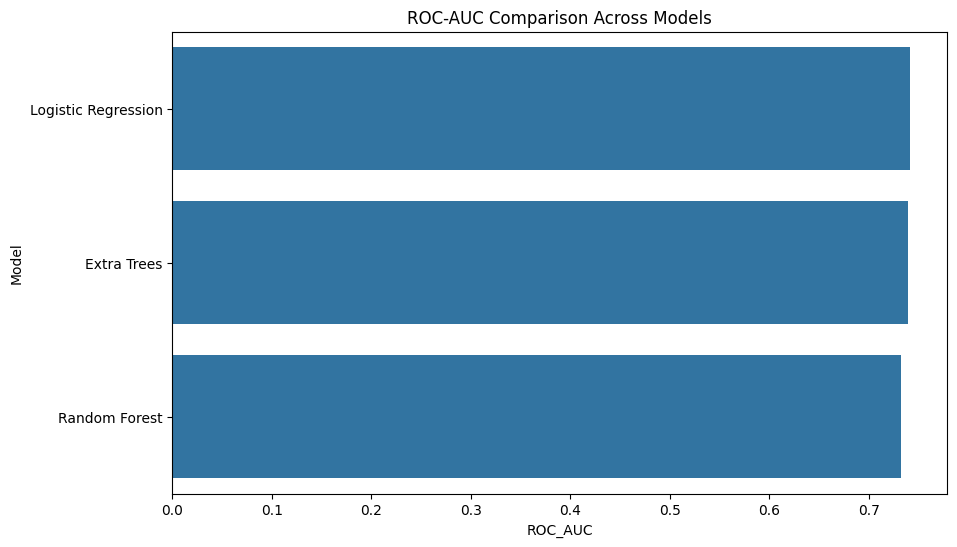

In [24]:
# =====================================================
# MODEL COMPARISON
# =====================================================

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

display(results_df)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="ROC_AUC",
    y="Model"
)

plt.title("ROC-AUC Comparison Across Models")
plt.show()

In [25]:
# =====================================================
# CROSS VALIDATION
# =====================================================

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring="roc_auc"
    )

    cv_results.append({
        "Model": name,
        "Mean ROC AUC": scores.mean(),
        "Std Dev": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

display(cv_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,Model,Mean ROC AUC,Std Dev
0,Logistic Regression,0.719681,0.026138
1,Random Forest,0.698595,0.025382
2,Extra Trees,0.700395,0.024155


In [30]:
# =====================================================
# RANDOM FOREST TUNING
# =====================================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "n_estimators":[100,200],

    "max_depth":[5,8,10],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

best_rf = search.best_estimator_

print(search.best_params_)

{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}


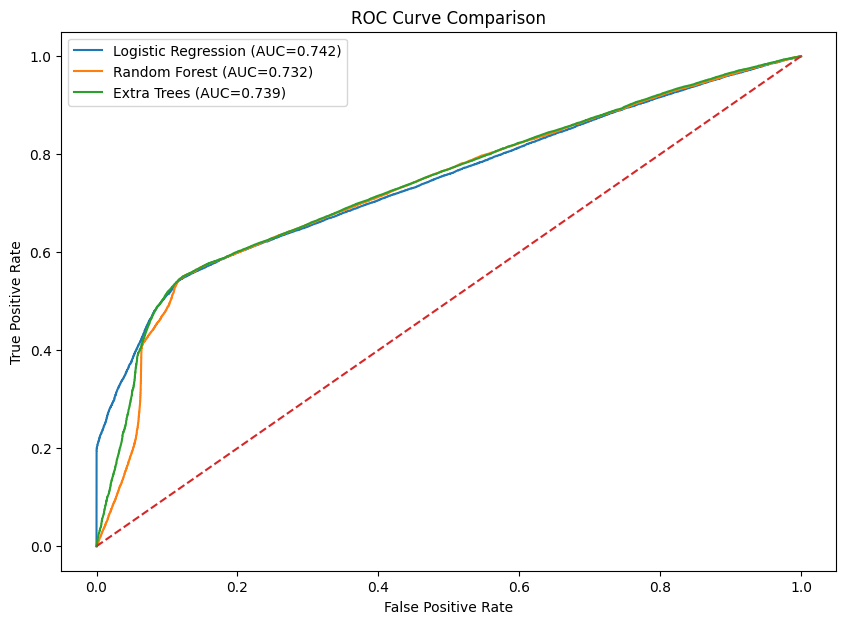

In [31]:
# =====================================================
# ROC CURVES
# =====================================================

from sklearn.metrics import roc_curve

plt.figure(figsize=(10,7))

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    auc = roc_auc_score(
        y_test,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

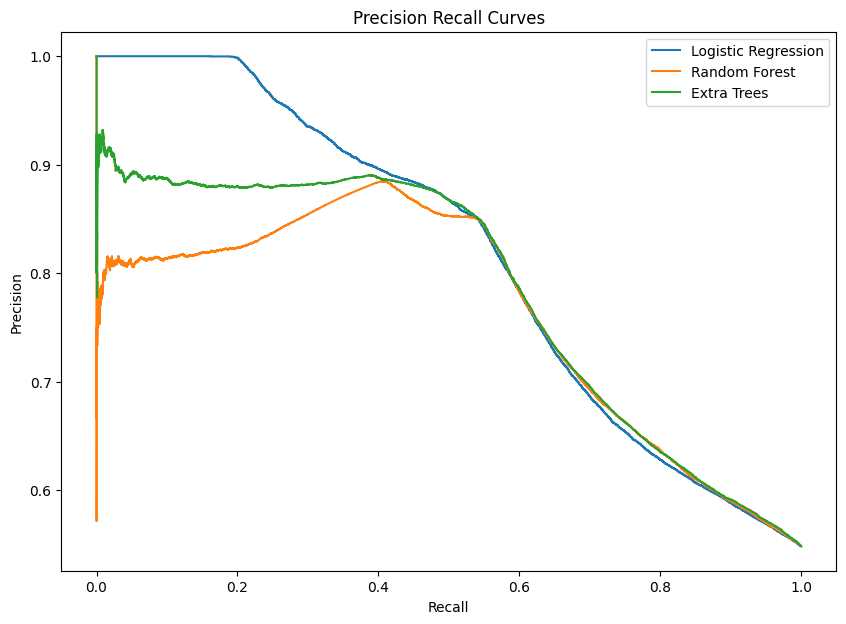

In [32]:
# =====================================================
# PRECISION RECALL CURVE
# =====================================================

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10,7))

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probs
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curves")

plt.legend()

plt.show()

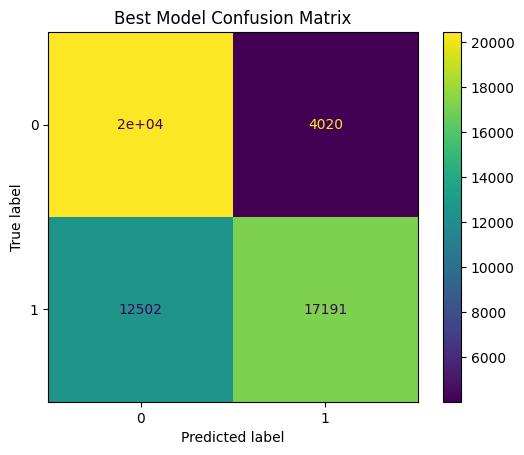

In [33]:
# =====================================================
# CONFUSION MATRIX
# =====================================================

from sklearn.metrics import ConfusionMatrixDisplay

best_model = best_rf

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("Best Model Confusion Matrix")
plt.show()

In [34]:
# =====================================================
# FEATURE SELECTION
# =====================================================

from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    best_rf,
    threshold="median"
)

selector.fit(
    X_train,
    y_train
)

selected_features = X_encoded.columns[
    selector.get_support()
]

print(selected_features)

Index(['Days for shipment (scheduled)', 'Product Price', 'Order Item Quantity',
       'Sales', 'Order Profit Per Order', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Total', 'Benefit per order',
       'Shipping Mode_Same Day',
       ...
       'Order Country_Tailandia', 'Order Country_Trinidad y Tobago',
       'Order Country_Turquía', 'Order Country_Túnez', 'Order Country_Ucrania',
       'Order Country_Uganda', 'Customer Country_Puerto Rico', 'Type_DEBIT',
       'Type_PAYMENT', 'Type_TRANSFER'],
      dtype='object', length=133)


In [35]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 13.8 MB/s eta 0:00:00


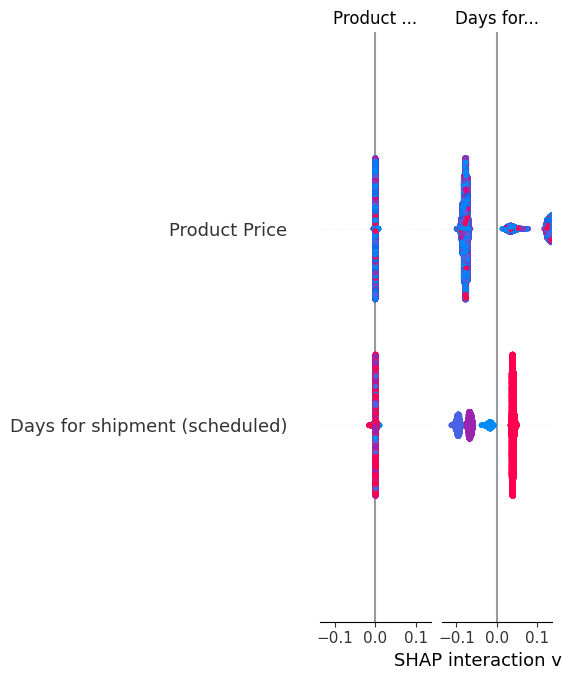

In [36]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [37]:
final_results = []

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    final_results.append({

        "Model": name,

        "Accuracy":
        accuracy_score(y_test,pred),

        "Precision":
        precision_score(y_test,pred),

        "Recall":
        recall_score(y_test,pred),

        "F1":
        f1_score(y_test,pred),

        "ROC_AUC":
        roc_auc_score(y_test,prob)
    })

comparison_df = pd.DataFrame(final_results)

comparison_df.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.695897,0.835703,0.554339,0.666545,0.741991
2,Extra Trees,0.692093,0.797486,0.587647,0.676672,0.739363
1,Random Forest,0.691964,0.797258,0.587613,0.676568,0.732303
